In [ ]:
import sqlite3
import pandas as pd

In [ ]:
conn = sqlite3.connect('datadb.db')
cursor = conn.cursor()

In [ ]:
# enable foreign key enforcement for SQLite connection
cursor.execute("PRAGMA foreign_keys = ON;")

In [ ]:
# load data
products = pd.read_csv('/content/products_cleaned.csv', index_col=0)
sales = pd.read_csv('/content/sales_cleaned.csv', index_col=0)
stores = pd.read_csv('/content/stores_cleaned.csv', index_col=0)
exchange = pd.read_csv('/content/exchange_rates_cleaned.csv', index_col=0)
customers = pd.read_csv('/content/customers_cleaned.csv', index_col=0)

In [ ]:
products.head()

,product_key,product_name,brand,color,unit_cost_usd,unit_price_usd,subcategory_key,subcategory,category_key,category,margin
0,1,Contoso 512MB MP3 Player E51 Silver,Contoso,Silver,6.62,12.99,101,MP4&MP3,1,Audio,6.37
1,2,Contoso 512MB MP3 Player E51 Blue,Contoso,Blue,6.62,12.99,101,MP4&MP3,1,Audio,6.37
2,3,Contoso 1G MP3 Player E100 White,Contoso,White,7.40,14.52,101,MP4&MP3,1,Audio,7.12
3,4,Contoso 2G MP3 Player E200 Silver,Contoso,Silver,11.00,21.57,101,MP4&MP3,1,Audio,10.57
4,5,Contoso 2G MP3 Player E200 Red,Contoso,Red,11.00,21.57,101,MP4&MP3,1,Audio,10.57


In [ ]:
# define table to store currency exchange rates
cursor.execute('''
CREATE TABLE IF NOT EXISTS exchange (
    date DATE,
    currency VARCHAR(3),
    exchange FLOAT,
    PRIMARY KEY (date, currency)
);
''')

In [ ]:
# define table to store customers information
cursor.execute('''
CREATE TABLE IF NOT EXISTS customers (
  customer_key INT PRIMARY KEY,
  gender VARCHAR(255) NOT NULL,
  name VARCHAR(50) NOT NULL,
  city VARCHAR(50) NOT NULL,
  state_code VARCHAR(10),
  state VARCHAR(50),
  zip_code VARCHAR(10),
  country VARCHAR(50),
  continent VARCHAR(50),
  birthday DATE NOT NULL
  );
''')

In [ ]:
# define table to store store information
cursor.execute('''
CREATE TABLE IF NOT EXISTS stores (
    store_key INTEGER PRIMARY KEY,
    country VARCHAR(20) NOT NULL,
    state VARCHAR(50) NOT NULL,
    square_meters FLOAT NOT NULL,
    open_date DATE NOT NULL
    );
''')

In [ ]:
# define table to store sales information
cursor.execute("""
CREATE TABLE sales (
    order_number INT,
    line_item INT,
    order_date DATE,
    delivery_date DATE,
    customer_key INT,
    store_key INT,
    product_key INT,
    quantity INT,
    currency_code VARCHAR(3),
    PRIMARY KEY (order_number, line_item),
    FOREIGN KEY (customer_key) REFERENCES customers(customer_key),
    FOREIGN KEY (store_key) REFERENCES stores(store_key),
    FOREIGN KEY (product_key) REFERENCES products(product_key)
);
""")

In [ ]:
# define table to store product details
cursor.execute('''
CREATE TABLE IF NOT EXISTS products (
    product_key INTEGER PRIMARY KEY,
    product_name VARCHAR(255) NOT NULL,
    brand VARCHAR(255) NOT NULL,
    color VARCHAR(255) NOT NULL,
    unit_cost_usd FLOAT NOT NULL,
    unit_price_usd FLOAT NOT NULL,
    subcategory_key INT NOT NULL,
    subcategory VARCHAR(255) NOT NULL,
    category_key INT NOT NULL,
    category VARCHAR(255),
    margin FLOAT
);
''')

In [ ]:
# insert data into table
products.to_sql("products", conn, if_exists="append", index=False)

2517

In [ ]:
stores.to_sql("stores", conn, if_exists="append", index=False)

67

In [ ]:
customers.to_sql("customers", conn, if_exists="append", index=False)

15266

In [ ]:
sales.to_sql("sales", conn, if_exists="append", index=False)

62884

In [ ]:
exchange.to_sql("exchange", conn, if_exists="append", index=False)

11215

In [ ]:
# menggabungkan semua kolom untuk dataset yang lengkap
dataset = pd.read_sql('''
SELECT s.*, c.*, p.*, e.*, st.*
FROM sales s
JOIN customers c ON s.customer_key = c.customer_key
JOIN products p ON s.product_key = p.product_key
JOIN exchange e ON s.currency_code = e.currency AND s.order_date = e.date
JOIN stores st ON s.store_key = st.store_key;
''', conn)

In [ ]:
dataset

,order_number,line_item,order_date,delivery_date,customer_key,store_key,product_key,quantity,currency_code,customer_key,...,category,margin,date,currency,exchange,store_key,country,state,square_meters,open_date
0,366000,1,2016-01-01,None,265598,10,1304,1,CAD,265598,...,Cameras and camcorders,36.73,2016-01-01,CAD,1.3884,10,Canada,Nunavut,1210.0,2015-04-04
1,366001,1,2016-01-01,2016-01-13,1269051,0,1048,2,USD,1269051,...,Cameras and camcorders,285.53,2016-01-01,USD,1.0000,0,Online,Online,0.0,2010-01-01
2,366001,2,2016-01-01,2016-01-13,1269051,0,2007,1,USD,1269051,...,Home Appliances,445.30,2016-01-01,USD,1.0000,0,Online,Online,0.0,2010-01-01
3,366002,1,2016-01-01,2016-01-12,266019,0,1106,7,CAD,266019,...,Cameras and camcorders,173.92,2016-01-01,CAD,1.3884,0,Online,Online,0.0,2010-01-01
4,366002,2,2016-01-01,2016-01-12,266019,0,373,1,CAD,266019,...,Computers,159.80,2016-01-01,CAD,1.3884,0,Online,Online,0.0,2010-01-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62879,2243030,1,2021-02-20,None,1216913,43,632,3,USD,1216913,...,Computers,68.13,2021-02-20,USD,1.0000,43,United States,Alaska,1190.0,2015-01-01
62880,2243031,1,2021-02-20,2021-02-24,511229,0,98,4,EUR,511229,...,Audio,64.82,2021-02-20,EUR,0.8238,0,Online,Online,0.0,2010-01-01
62881,2243032,1,2021-02-20,2021-02-23,331277,0,1613,2,CAD,331277,...,"Music, Movies and Audio Books",53.91,2021-02-20,CAD,1.2610,0,Online,Online,0.0,2010-01-01
62882,2243032,2,2021-02-20,2021-02-23,331277,0,1717,2,CAD,331277,...,Games and Toys,37.88,2021-02-20,CAD,1.2610,0,Online,Online,0.0,2010-01-01


In [ ]:
dataset.to_csv('dataset.csv')

### Customer Analysis
-  demographic distribution : distribution of customers based on gender, age (from birthdate), location (city, state, country, continent)
- purchased patterns : identify purchasing patterns such as average order value, frequency of purchases, and preferred products

### Sales Analysis
- Overall sales performance : total sales over time, identifying trends and seasonality
- Sales by product : which products are the top performers based on quantity and revenue generated
- sales by store: assess the performance of difference storea based on sales data
- sales by currency : examine how different currencies impact sales figures, considering exchange rates

In [21]:
# 1. distrubution customers based on gender
pd.read_sql("""
SELECT gender, COUNT(*) AS count
FROM customers
GROUP BY gender
;
""", conn)

,gender,count
0,Female,7518
1,Male,7748


In [22]:
# customers yang membeli
pd.read_sql("""
SELECT c.gender, COUNT(DISTINCT s.customer_key) AS customer_count
FROM sales s
JOIN customers c ON s.customer_key = c.customer_key
GROUP BY c.gender
;
""", conn)

,gender,customer_count
0,Female,5858
1,Male,6029


In [23]:
# Distribution of orders by age
pd.read_sql("""
SELECT
  age,
  COUNT(*) AS total_orders
FROM (
  SELECT
    CAST((julianday(s.order_date) - julianday(c.birthday)) / 365.25 AS INT) AS age
  FROM sales s
  JOIN customers c ON s.customer_key = c.customer_key
)
GROUP BY age
ORDER BY age;
""", conn)

,age,total_orders
0,14,45
1,15,246
2,16,360
3,17,684
4,18,1011
...,...,...
67,81,831
68,82,827
69,83,578
70,84,314


In [ ]:
# Distribution of orders by age group
pd.read_sql("""
SELECT
  age_group,
  COUNT(*) AS total_orders
FROM (
  SELECT
    CASE
      WHEN CAST((julianday(s.order_date) - julianday(c.birthday)) / 365.25 AS INT) < 12 THEN 'child'
      WHEN CAST((julianday(s.order_date) - julianday(c.birthday)) / 365.25 AS INT) < 18 THEN 'teenager'
      WHEN CAST((julianday(s.order_date) - julianday(c.birthday)) / 365.25 AS INT) < 30 THEN 'young adult'
      WHEN CAST((julianday(s.order_date) - julianday(c.birthday)) / 365.25 AS INT) < 60 THEN 'adult'
      ELSE 'senior'
    END AS age_group
  FROM sales s
  JOIN customers c ON s.customer_key = c.customer_key
)
GROUP BY age_group
ORDER BY total_orders DESC;
""", conn)

,age_group,total_orders
0,adult,27945
1,senior,22125
2,young adult,11479
3,teenager,1335


In [24]:
revenue_by_age_group = pd.read_sql("""
SELECT
  gender,
  age_group,
  COUNT(*) AS total_transactions,
  SUM(revenue) AS total_revenue
FROM (
  SELECT
    c.gender,
    (s.quantity * p.unit_price_usd) as revenue,
    CASE
      WHEN CAST((julianday(s.order_date) - julianday(c.birthday)) / 365.25 AS INT) < 12 THEN 'child'
      WHEN CAST((julianday(s.order_date) - julianday(c.birthday)) / 365.25 AS INT) < 18 THEN 'teenager'
      WHEN CAST((julianday(s.order_date) - julianday(c.birthday)) / 365.25 AS INT) < 30 THEN 'young adult'
      WHEN CAST((julianday(s.order_date) - julianday(c.birthday)) / 365.25 AS INT) < 60 THEN 'adult'
      ELSE 'senior'
    END AS age_group
  FROM sales s
  JOIN customers c ON s.customer_key = c.customer_key
  JOIN products p ON s.product_key = p.product_key
)
GROUP BY gender, age_group
ORDER BY SUM(revenue) DESC, age_group, gender;
""", conn)


In [25]:
revenue_by_age_group.style.format({'total_revenue': '{:,.0f}'})

,gender,age_group,total_transactions,total_revenue
0,Male,adult,14035,"12,355,960"
1,Female,adult,13910,"12,288,952"
2,Male,senior,11291,"10,256,611"
3,Female,senior,10834,"9,413,987"
4,Female,young adult,5655,"5,121,752"
5,Male,young adult,5824,"5,117,328"
6,Male,teenager,654,"604,956"
7,Female,teenager,681,"595,934"


In [26]:
pd.read_sql("""
WITH margin AS (
    SELECT *, (unit_price_usd - unit_cost_usd) as margin
    FROM products
    GROUP BY brand
)
SELECT brand, color, SUM(margin) as margin
FROM margin
GROUP BY brand
ORDER BY margin DESC, brand, color
""", conn)


,brand,color,margin
0,Proseware,Black,868.62
1,Fabrikam,Black,801.75
2,The Phone Company,Black,353.73
3,Litware,Black,323.54
4,Adventure Works,Silver,83.32
5,Wide World Importers,White,73.50
6,A. Datum,Black,69.68
7,Southridge Video,Black,64.28
8,Northwind Traders,Blue,12.59
9,Contoso,Silver,6.37


In [32]:
stores

,store_key,country,state,square_meters,open_date
0,1,Australia,Australian Capital Territory,595,2008-01-01
1,2,Australia,Northern Territory,665,2008-01-12
2,3,Australia,South Australia,2000,2012-01-07
3,4,Australia,Tasmania,2000,2010-01-01
4,5,Australia,Victoria,2000,2015-12-09
...,...,...,...,...,...
62,63,United States,Utah,2000,2008-03-06
63,64,United States,Washington DC,1330,2010-01-01
64,65,United States,West Virginia,1785,2012-01-01
65,66,United States,Wyoming,840,2014-01-01


In [33]:
order_line = pd.read_sql("""
WITH order_cte AS(
  SELECT s.*, (p.unit_price_usd * s.quantity) as revenue, (p.unit_cost_usd * s.quantity) as cost
  FROM sales s
  JOIN products p ON s.product_key = p.product_key
)
SELECT
  o.order_number,
  SUM(o.quantity) as total_item,
  c.customer_key,
  CAST((julianday(o.order_date) - julianday(c.birthday))/365.25 AS INT) as age,
  o.order_date,
  SUM(o.revenue) as total_revenue,
  SUM(o.cost) as total_cost,
  SUM(o.revenue - o.cost) as total_profit,
  CASE
    WHEN o.store_key != 0 THEN 'Offline'
    ELSE 'Online'
  END AS store_type
FROM order_cte o
JOIN customers c ON o.order_number = c.customer_key
JOIN stores st ON o.store_key = st.store_key
GROUP BY o.order_date, o.order_number
ORDER BY o.order_date, o.order_number, total_revenue DESC
""", conn)
order_line

,order_number,total_item,customer_key,age,order_date,total_revenue,total_cost,total_profit,store_type
0,367004,5,367004,74,2016-01-02,421.91,194.01,227.90,Offline
1,378008,2,378008,63,2016-01-13,119.98,55.18,64.80,Offline
2,379002,7,379002,56,2016-01-14,3643.95,1241.50,2402.45,Online
3,391003,7,391003,73,2016-01-26,137.38,67.66,69.72,Offline
4,400009,2,400009,41,2016-02-04,218.00,72.22,145.78,Offline
...,...,...,...,...,...,...,...,...,...
160,1981004,8,1981004,71,2020-06-03,2376.88,1109.53,1267.35,Offline
161,1986003,4,1986003,74,2020-06-08,119.80,55.08,64.72,Offline
162,1998013,3,1998013,71,2020-06-20,43.70,22.27,21.43,Offline
163,2072003,1,2072003,27,2020-09-02,4.99,2.54,2.45,Online


In [ ]:
order_line['order_date'] = pd.to_datetime(order_line['order_date'])

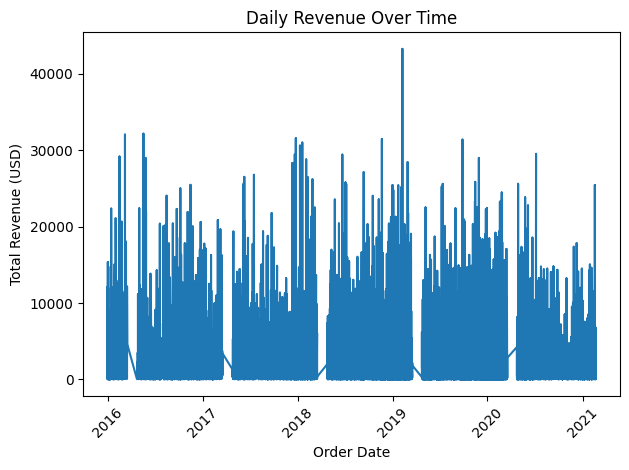

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(order_line['order_date'], order_line['total_revenue'])
plt.xlabel('Order Date')
plt.ylabel('Total Revenue (USD)')
plt.title('Daily Revenue Over Time')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
order_line['month'] = order_line['order_date'].dt.to_period('M')

monthly = (
    order_line
    .groupby('month')['total_revenue']
    .sum()
    .reset_index()
)

monthly['month'] = monthly['month'].dt.to_timestamp()


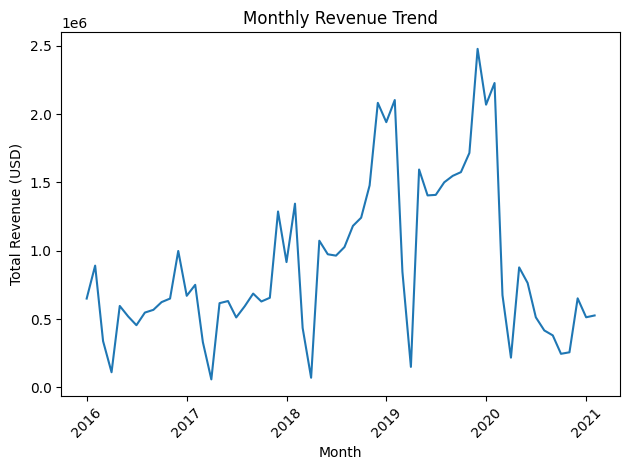

In [ ]:
plt.figure()
plt.plot(monthly['month'], monthly['total_revenue'])
plt.xlabel('Month')
plt.ylabel('Total Revenue (USD)')
plt.title('Monthly Revenue Trend')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
